# MMIP - Week 3（基礎版）
使用 Kaggle 的 Animals Detection Images Dataset（本作業選用其中 50 個動物類別），依序完成「準備資料集 → 訓練 CNN 影像分類模型 → 提升泛化能力」三個 Quiz 的基礎題。

| Quiz | 內容 |
|---|---|
| Quiz 1 | 準備資料集（Kaggle / kagglehub）、K-Fold 切分、問題定義 |
| Quiz 2 | Plain CNN 與經典 Backbone（ResNet-18）訓練、Top-1/Top-5、ROC / Macro-AUC |
| Quiz 3 | Data Augmentation 前後比較（Plain CNN 與 ResNet-18） |

執行方式：請由上而下依序執行所有 cell。第一次執行時會自動下載資料集，並把所有影像縮成 224×224 後快取成 .npy（存放在 outputs/，約數十秒），之後會直接載入快取。

加速設計：原圖約 1024×768，若每個 epoch 都從硬碟重新解碼會非常慢。因此本 notebook 先一次性縮圖並快取，訓練時整批資料放在 GPU 上，資料擴增也在 GPU 上完成，不需要 DataLoader worker。

執行環境：NVIDIA GeForce RTX 3060、PyTorch

In [14]:
import os, random, time, copy, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from PIL import Image
from torchvision import transforms, models

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc

warnings.filterwarnings("ignore")

SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
set_seed()
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"   # 讓編號和 nvidia-smi 一致

GPU_NAME_KEYWORD = "3060"   # 用名稱找卡，避免編號對不上
DEVICE = "cpu"
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))
    match = [i for i in range(torch.cuda.device_count())
             if GPU_NAME_KEYWORD in torch.cuda.get_device_name(i)]
    DEVICE = f"cuda:{match[0] if match else 0}"
    torch.cuda.set_device(DEVICE)   # 讓預設的 cuda 操作也落在這張卡
USE_AMP = DEVICE.startswith("cuda")
AMP_DEV = "cuda" if USE_AMP else "cpu"
print("device:", DEVICE)

# ---------------- 全域設定（可自行調整） ----------------
CFG = dict(
    IMG_SIZE=224,
    BATCH=64,
    N_SPLITS=5,        # K-Fold 的 K
    FOLD=0,            # 實際用來訓練的那一個 fold
    MAX_CLASSES=50,  # None = 使用全部類別（80 類）；除錯時可設 20
    MIN_PER_CLASS=30,  # 清理後訓練池中少於此張數的類別會被丟棄（確保 K-Fold 每折都有該類別）
    DROP_CONFLICT=True,  # 同一張圖同時出現在多個類別資料夾 → 標籤衝突，整張丟棄
    CHECK_IMAGES=False,  # 損毀影像在建立快取時會被偵測並以黑圖取代，這裡不必再逐張檢查
    EPOCHS_PLAIN=15,
    EPOCHS_RESNET=15,
)
# 主模型使用的超參數（Quiz 2 進階實驗後可更新）
PLAIN_HP  = dict(lr=1e-3, opt="adamw", wd=1e-4, batch=64, dropout=0.3, width=32, ls=0.0)
RESNET_HP = dict(lr=3e-4, opt="adamw", wd=1e-4, batch=64, freeze=False, ls=0.0)

OUT = Path("outputs"); OUT.mkdir(exist_ok=True)

# 全域結果容器
MODELS, HIST, PROBS, TEST, PARAMS = {}, {}, {}, {}, {}

0 NVIDIA GeForce RTX 3060
device: cuda:0


# Quiz 1：準備資料集

## 1-1 資料來源與內容（kagglehub）

- **資料集**：[Animals Detection Images Dataset（antoreepjana/animals-detection-images-dataset）](https://www.kaggle.com/datasets/antoreepjana/animals-detection-images-dataset)，
  取自 Open Images 的野生動物影像，共 **80 個動物類別**（Bear、Lion、Zebra、Penguin……）。
- **目錄結構**：`train/<類別>/xxx.jpg`、`test/<類別>/xxx.jpg`；每個類別資料夾內另有 `Label/xxx.txt`（物件偵測的 bounding box 標註）。
  本作業做的是**影像分類**，所以只使用 jpg 影像與「資料夾名稱 = 類別」，**不使用 `Label/` 內的 txt**，也不能直接用 `ImageFolder`（它會把 `Label` 當成一個類別）。
- **選擇原因**：類別多（80 類）、有官方 train / test 切分、影像來自真實場景（背景、遮擋、多隻動物），
  適合觀察 Top-5、Macro-AUC、資料擴增與 Grad-CAM。
- **已知的資料問題（本 notebook 會逐一檢查並修正）**：
  1. 影像是為「偵測」而蒐集的，同一張圖可能出現在多個類別資料夾（例如同時有 Bear 與 Brown bear）→ **標籤衝突**；
  2. 可能有完全重複的檔案，且重複圖可能同時出現在 train 與 test → **資料洩漏**；
  3. 可能有損毀 / 無法開啟的影像；
  4. 各類別張數不平衡。
- **用法**：官方 `train` 作為訓練池，再以 Stratified K-Fold 產生訓練 / 驗證集；官方 `test` 作為獨立測試集，完全不參與訓練與調參。

> 實際張數、類別數與檢查結果以下方程式輸出為準。

In [2]:
import kagglehub

root = Path(kagglehub.dataset_download("antoreepjana/animals-detection-images-dataset"))
print("dataset path:", root)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def split_of(p: Path):
    """由路徑判斷屬於 train / test / validation（資料夾名稱比對，不分大小寫）"""
    parts = [x.lower() for x in p.relative_to(root).parts]
    for s in ("train", "test", "validation", "val"):
        if s in parts:
            return "validation" if s == "val" else s
    return None

rows = []
for p in root.rglob("*"):
    if p.suffix.lower() in IMG_EXT and p.parent.name.lower() != "label":
        rows.append(dict(path=str(p), split=split_of(p), cls=p.parent.name))
index = pd.DataFrame(rows)
print(f"找到影像 {len(index)} 張；各 split 張數：\n{index.split.value_counts(dropna=False).to_string()}")
print(f"類別數（資料夾名稱）= {index.cls.nunique()}")
display(index.head())

dataset path: C:\Users\GM100\.cache\kagglehub\datasets\antoreepjana\animals-detection-images-dataset\versions\7
找到影像 29071 張；各 split 張數：
split
train    22566
test      6505
類別數（資料夾名稱）= 80


,path,split,cls
0,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Bear
1,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Bear
2,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Bear
3,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Bear
4,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Bear


In [3]:
import hashlib

# 只保留 train / test；validation（若有）不使用，因為驗證集由 K-Fold 從 train 產生
index = index[index.split.isin(["train", "test"])].reset_index(drop=True)
assert {"train", "test"} <= set(index.split), "找不到 train 或 test 資料夾，請檢查上方 dataset path 的目錄結構"

# (1) 損毀影像：逐張開檔 verify
def is_ok(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

if CFG["CHECK_IMAGES"]:
    index["ok"] = [is_ok(p) for p in index.path]
    print(f"[損毀影像] {int((~index.ok).sum())} 張")
    index = index[index.ok].drop(columns="ok").reset_index(drop=True)

# (2) 檔案內容 MD5：找出完全重複的影像
def md5(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

index["md5"] = [md5(p) for p in index.path]
g = index.groupby("md5")
dup_groups = g.filter(lambda d: len(d) > 1)
print(f"[重複影像] 涉及 {dup_groups.md5.nunique()} 組、共 {len(dup_groups)} 張")

# (3) 標籤衝突：同一內容出現在 2 個以上不同類別
conflict_md5 = set(g.cls.nunique()[lambda s: s > 1].index)
print(f"[標籤衝突] 內容相同但類別不同的影像組數 = {len(conflict_md5)}")
display(index[index.md5.isin(conflict_md5)].sort_values("md5").head(10))

# (4) 資料洩漏：同一內容同時出現在 train 與 test
leak_md5 = set(g.split.nunique()[lambda s: s > 1].index)
print(f"[train/test 洩漏] 同時出現在 train 與 test 的影像組數 = {len(leak_md5)}")

[重複影像] 涉及 1305 組、共 2724 張
[標籤衝突] 內容相同但類別不同的影像組數 = 1305


,path,split,cls,md5
14810,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Harbor seal,000a7efcc9ef6c6c505dfbde8c8a9ac0
23438,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Sea lion,000a7efcc9ef6c6c505dfbde8c8a9ac0
14806,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Harbor seal,000e6dadfbf64e9219ae32e8ac270e0d
23435,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Sea lion,000e6dadfbf64e9219ae32e8ac270e0d
15631,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Jaguar,003607dfb32fdd007ee7ad585506b741
16742,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Leopard,003607dfb32fdd007ee7ad585506b741
14463,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Goose,00731a7c880836b47b0be47e0d17490b
10875,C:\Users\GM100\.cache\kagglehub\datasets\antor...,train,Duck,00731a7c880836b47b0be47e0d17490b
6328,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Turkey,00e7763dd3367bd0e40f35b858b278f1
687,C:\Users\GM100\.cache\kagglehub\datasets\antor...,test,Chicken,00e7763dd3367bd0e40f35b858b278f1


[train/test 洩漏] 同時出現在 train 與 test 的影像組數 = 0


資料修正：29071 → 26347 張（移除 2724 張）
使用 50 個類別；train 池 16201 張，test 4141 張


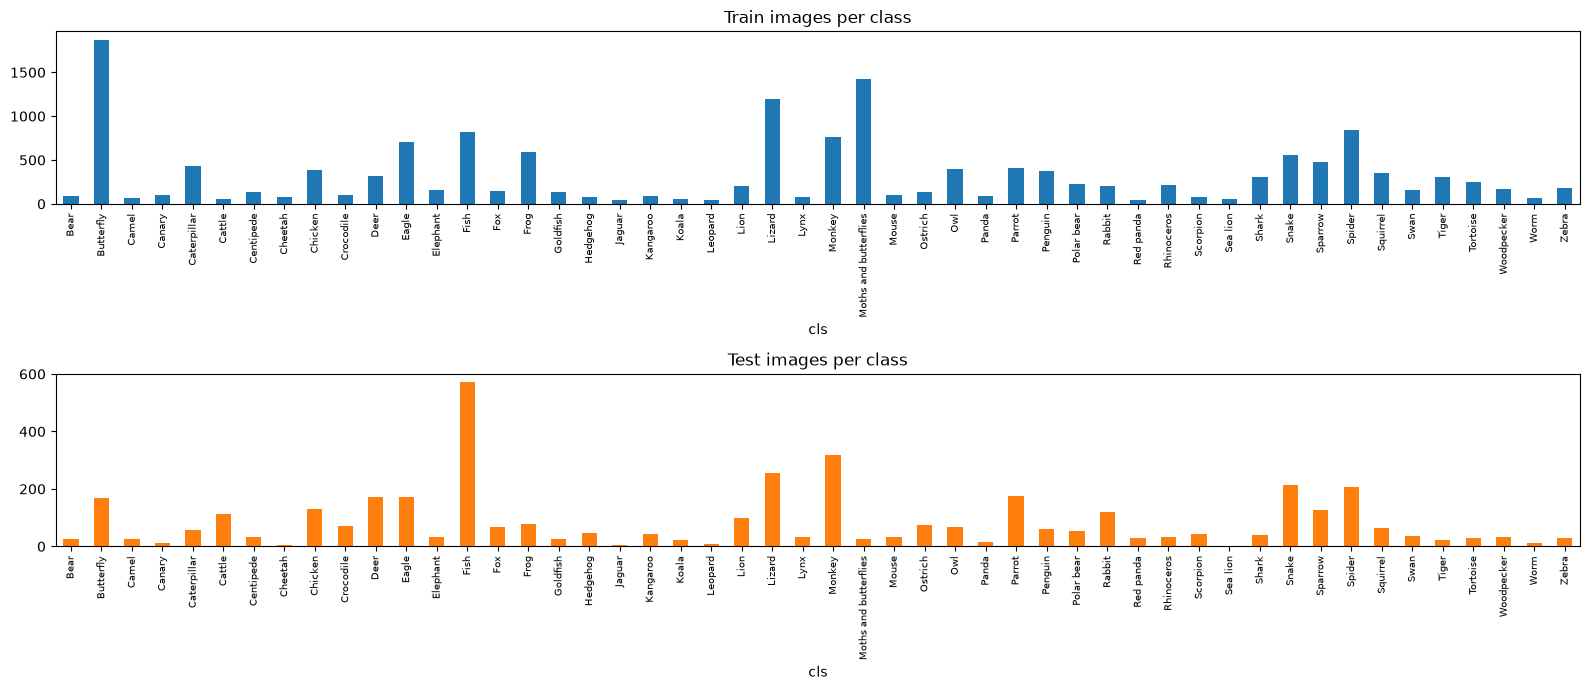

訓練池每類張數 min/median/max = 40/174/1874（不平衡比 46.9:1）
抽樣 400 張的寬 / 高：中位數 1024 x 768，最小 [516, 406]，最大 [1024, 1024]


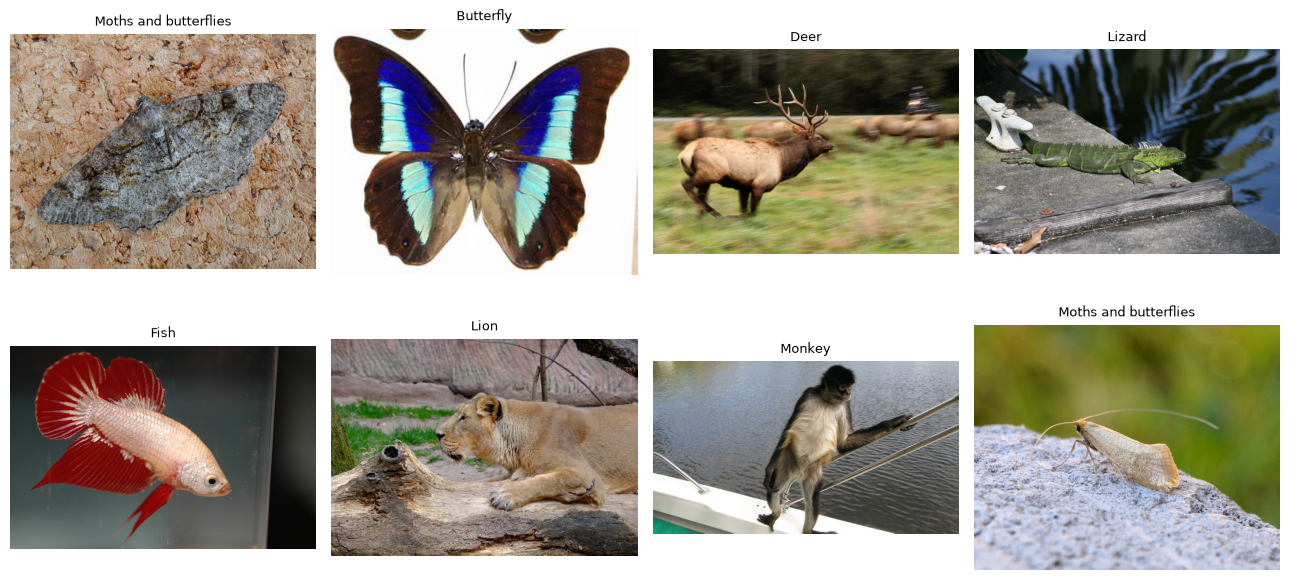

In [4]:
# ---------- 資料修正 ----------
before = len(index)
if CFG["DROP_CONFLICT"]:
    index = index[~index.md5.isin(conflict_md5)]          # 標籤不確定 → 整組丟棄
# 洩漏的影像：從 test 移除（保持 test 完全獨立；train 內保留一份）
index = index[~((index.split == "test") & index.md5.isin(leak_md5))]
# 同一 split 內完全重複的影像：只保留第一張
index = index.drop_duplicates(subset=["split", "md5"]).reset_index(drop=True)
print(f"資料修正：{before} → {len(index)} 張（移除 {before - len(index)} 張）")

# 類別過濾：訓練池張數太少的類別會讓 K-Fold 失效
train_cnt = index[index.split == "train"].cls.value_counts()
keep = sorted(train_cnt[train_cnt >= CFG["MIN_PER_CLASS"]].index)
if CFG["MAX_CLASSES"]:
    rng = np.random.RandomState(SEED)
    keep = sorted(rng.choice(keep, min(CFG["MAX_CLASSES"], len(keep)), replace=False).tolist())
index = index[index.cls.isin(keep)].reset_index(drop=True)

CLASSES = keep
NUM_CLASSES = len(CLASSES)
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
index["label"] = index.cls.map(CLS2IDX)
print(f"使用 {NUM_CLASSES} 個類別；train 池 {int((index.split=='train').sum())} 張，test {int((index.split=='test').sum())} 張")

# ---------- 類別分佈 + 影像尺寸 + 範例 ----------
tr_cnt = index[index.split == "train"].cls.value_counts().reindex(CLASSES)
te_cnt = index[index.split == "test"].cls.value_counts().reindex(CLASSES, fill_value=0)
fig, ax = plt.subplots(2, 1, figsize=(16, 7))
tr_cnt.plot.bar(ax=ax[0], title="Train images per class"); ax[0].tick_params(axis="x", labelsize=7)
te_cnt.plot.bar(ax=ax[1], color="tab:orange", title="Test images per class"); ax[1].tick_params(axis="x", labelsize=7)
plt.tight_layout(); plt.show()
print(f"訓練池每類張數 min/median/max = {tr_cnt.min()}/{int(tr_cnt.median())}/{tr_cnt.max()}（不平衡比 {tr_cnt.max()/tr_cnt.min():.1f}:1）")

samp = index.sample(min(400, len(index)), random_state=SEED)
sizes = np.array([Image.open(p).size for p in samp.path])
print(f"抽樣 {len(samp)} 張的寬 / 高：中位數 {int(np.median(sizes[:,0]))} x {int(np.median(sizes[:,1]))}，"
      f"最小 {sizes.min(0).tolist()}，最大 {sizes.max(0).tolist()}")

pick = index[index.split == "train"].sample(8, random_state=SEED)
fig, axs = plt.subplots(2, 4, figsize=(13, 6.5))
for a, (_, r) in zip(axs.ravel(), pick.iterrows()):
    a.imshow(Image.open(r.path).convert("RGB")); a.set_title(r.cls, fontsize=9); a.axis("off")
plt.tight_layout(); plt.show()

## 1-2 訓練 / 驗證切分（Stratified K-Fold）

- 對 `train/` 使用 **StratifiedKFold（K=5，shuffle，固定亂數種子）**，每個 fold 內各類別比例與整體一致。
- 後續實驗以 **Fold 0** 為主要訓練 / 驗證切分（`CFG["FOLD"]` 可更換）；其餘 fold 可用同一套程式碼重複，
  以估計平均表現與變異（時間足夠時可跑全部 fold）。
- `test/` 作為最終獨立測試集，**不參與任何超參數選擇**。

In [5]:
import hashlib
from concurrent.futures import ThreadPoolExecutor

IMG = CFG["IMG_SIZE"]
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
torch.backends.cudnn.benchmark = True

class AnimalDS:
    """只存放 (路徑, 標籤)；影像本身另外快取成 uint8 陣列（不使用 ImageFolder，因為每個類別底下還有 Label/ 資料夾）"""
    def __init__(self, df):
        self.samples = list(zip(df.path.tolist(), df.label.astype(int).tolist()))
        self.targets = [s[1] for s in self.samples]
    def __len__(self):
        return len(self.samples)

def load_resized(path):
    try:
        with Image.open(path) as im:
            im.draft("RGB", (IMG, IMG))          # JPEG 解碼時直接縮小，比完整解碼 1024x768 快數倍
            return np.asarray(im.convert("RGB").resize((IMG, IMG), Image.BILINEAR))
    except Exception as e:
        print("讀取失敗，以黑圖代替:", path, e)
        return np.zeros((IMG, IMG, 3), np.uint8)

def build_cache(df, name):
    key = hashlib.md5("|".join(df.path).encode()).hexdigest()[:8]
    f = OUT / f"cache_{name}_{IMG}_{key}.npy"
    if f.exists():
        print(f"載入快取 {f}"); return np.load(f)
    t0 = time.time()
    arr = np.empty((len(df), IMG, IMG, 3), np.uint8)
    paths = df.path.tolist()
    def work(i): arr[i] = load_resized(paths[i])
    with ThreadPoolExecutor(8) as ex:
        for k, _ in enumerate(ex.map(work, range(len(paths)))):
            if (k + 1) % 2000 == 0:
                print(f"  [{name}] {k + 1}/{len(paths)}  {time.time() - t0:.0f}s")
    np.save(f, arr)
    print(f"[{name}] 完成 {len(df)} 張，用時 {time.time() - t0:.0f}s，已存 {f}")
    return arr

tr_df = index[index.split == "train"].reset_index(drop=True)
te_df = index[index.split == "test"].reset_index(drop=True)
BASE_TRAIN, BASE_TEST = AnimalDS(tr_df), AnimalDS(te_df)
TEST_DS = BASE_TEST     # test_report 會用到 .samples（路徑）

def to_dev(arr):        # (N,H,W,3) uint8 -> (N,3,H,W) uint8，整批放進 GPU
    return torch.from_numpy(arr).permute(0, 3, 1, 2).contiguous().to(DEVICE)

X_TRAIN, X_TEST = to_dev(build_cache(tr_df, "train")), to_dev(build_cache(te_df, "test"))
Y_TRAIN = torch.tensor(BASE_TRAIN.targets, device=DEVICE)
Y_TEST  = torch.tensor(BASE_TEST.targets, device=DEVICE)
print("影像張量:", tuple(X_TRAIN.shape), tuple(X_TEST.shape), "| device:", X_TRAIN.device)

targets = np.array(BASE_TRAIN.targets)
skf = StratifiedKFold(n_splits=CFG["N_SPLITS"], shuffle=True, random_state=SEED)
FOLDS = list(skf.split(np.zeros(len(targets)), targets))

display(pd.DataFrame([
    dict(fold=k, train=len(tr), val=len(va), val_classes=len(np.unique(targets[va])))
    for k, (tr, va) in enumerate(FOLDS)
]).set_index("fold"))

  [train] 2000/16201  1s
  [train] 4000/16201  2s
  [train] 6000/16201  3s
  [train] 8000/16201  4s
  [train] 10000/16201  5s
  [train] 12000/16201  6s
  [train] 14000/16201  7s
  [train] 16000/16201  8s
[train] 完成 16201 張，用時 15s，已存 outputs\cache_train_224_fcc20c1c.npy
  [test] 2000/4141  1s
  [test] 4000/4141  2s
[test] 完成 4141 張，用時 5s，已存 outputs\cache_test_224_2f2f11eb.npy
影像張量: (16201, 3, 224, 224) (4141, 3, 224, 224) | device: cuda:0


,train,val,val_classes
fold,,,
0,12960,3241,50
1,12961,3240,50
2,12961,3240,50
3,12961,3240,50
4,12961,3240,50


In [6]:
import math
MEAN_T = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
STD_T  = torch.tensor(STD,  device=DEVICE).view(1, 3, 1, 1)

def gpu_augment(x):
    """x: (B,3,H,W) float [0,1]。每張圖各自抽樣參數：
    RandomResizedCrop(scale 0.5-1) + 水平翻轉(p=0.5) + 旋轉(±15°)，以一次 affine_grid/grid_sample 完成，再做 ColorJitter。"""
    B, _, H, W = x.shape; dev = x.device
    U = lambda lo, hi: torch.empty(B, device=dev).uniform_(lo, hi)
    area = U(0.5, 1.0); ratio = torch.exp(U(math.log(3 / 4), math.log(4 / 3)))
    sw = torch.sqrt(area * ratio).clamp(max=1.0); sh = torch.sqrt(area / ratio).clamp(max=1.0)
    tx = U(-1, 1) * (1 - sw); ty = U(-1, 1) * (1 - sh)
    ang = U(-15, 15) * math.pi / 180
    flip = torch.where(torch.rand(B, device=dev) < 0.5, -1.0, 1.0)
    cos, sin = torch.cos(ang), torch.sin(ang)
    theta = torch.stack([
        torch.stack([sw * cos * flip, -sw * sin, tx], 1),
        torch.stack([sh * sin * flip,  sh * cos, ty], 1)], 1)                      # (B,2,3)
    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
    # ColorJitter：亮度 / 對比 / 飽和度 各 ±0.3
    b = U(0.7, 1.3).view(B, 1, 1, 1); c = U(0.7, 1.3).view(B, 1, 1, 1); s = U(0.7, 1.3).view(B, 1, 1, 1)
    x = (x * b).clamp(0, 1)
    m = x.mean(dim=(1, 2, 3), keepdim=True); x = ((x - m) * c + m).clamp(0, 1)
    g = (0.299 * x[:, 0:1] + 0.587 * x[:, 1:2] + 0.114 * x[:, 2:3]); x = ((x - g) * s + g).clamp(0, 1)
    return x

def random_erase(x, p=0.25, scale=(0.02, 0.15)):
    """RandomErasing（作用在已正規化的影像上，填 0 = 平均色）"""
    B, _, H, W = x.shape; dev = x.device
    area = torch.empty(B, device=dev).uniform_(*scale) * H * W
    ratio = torch.exp(torch.empty(B, device=dev).uniform_(math.log(0.3), math.log(3.3)))
    eh = torch.sqrt(area * ratio).clamp(max=H - 1); ew = torch.sqrt(area / ratio).clamp(max=W - 1)
    y0 = torch.rand(B, device=dev) * (H - eh); x0 = torch.rand(B, device=dev) * (W - ew)
    ys = torch.arange(H, device=dev).view(1, H, 1); xs = torch.arange(W, device=dev).view(1, 1, W)
    mask = (ys >= y0.view(B, 1, 1)) & (ys < (y0 + eh).view(B, 1, 1)) & \
           (xs >= x0.view(B, 1, 1)) & (xs < (x0 + ew).view(B, 1, 1)) & (torch.rand(B, device=dev) < p).view(B, 1, 1)
    return x.masked_fill(mask.unsqueeze(1), 0.0)

class GPULoader:
    """從 GPU 上的 uint8 張量直接取 batch；train=True 時打亂並丟掉最後不足一批，aug=True 時做資料擴增。"""
    def __init__(self, X, Y, idx, batch, train=False, aug=False):
        self.X, self.Y, self.batch, self.train, self.aug = X, Y, batch, train, aug
        self.idx = torch.as_tensor(np.asarray(idx), device=X.device)
    def __len__(self):
        n = len(self.idx)
        return n // self.batch if self.train else math.ceil(n / self.batch)
    def __iter__(self):
        idx = self.idx[torch.randperm(len(self.idx), device=self.idx.device)] if self.train else self.idx
        for i in range(len(self)):
            b = idx[i * self.batch:(i + 1) * self.batch]
            x = self.X[b].float().div_(255); y = self.Y[b]
            if self.aug: x = gpu_augment(x)
            x = (x - MEAN_T) / STD_T
            if self.aug: x = random_erase(x)
            yield x, y

def make_loaders(aug=False, fold=None, batch=None):
    """aug=False：不擴增（Quiz 2）；aug=True：訓練集擴增（Quiz 3）。驗證集永遠不擴增。"""
    fold = CFG["FOLD"] if fold is None else fold
    batch = batch or CFG["BATCH"]
    tr_idx, va_idx = FOLDS[fold]
    return (GPULoader(X_TRAIN, Y_TRAIN, tr_idx, batch, train=True, aug=aug),
            GPULoader(X_TRAIN, Y_TRAIN, va_idx, batch * 2))

TEST_LOADER = GPULoader(X_TEST, Y_TEST, np.arange(len(BASE_TEST)), 128)

tr_loader, va_loader = make_loaders(False)
print(f"Fold {CFG['FOLD']}: train batches={len(tr_loader)}, val batches={len(va_loader)}, test images={len(BASE_TEST)}")

Fold 0: train batches=202, val batches=26, test images=4141


## 1-3 問題定義
- 任務類型：單標籤、多類別影像分類（multi-class image classification）。
  - 輸入：一張 RGB 動物影像（縮放為 224 × 224）。
  - 輸出：50 個動物類別的機率分佈（Softmax），機率最高者為預測類別。隨機猜測的 Top-1 準確率約為 1 / 50 = 2%，Top-5 約為 10%。
- 資料類別：從原始 80 種動物中選出 50 種（MAX_CLASSES = 50；訓練池每類至少 30 張，隨機種子固定，資料夾名稱即類別名稱），涵蓋哺乳類、鳥類、魚類、昆蟲等。其中有外觀相近的類別，例如 Bear / Polar bear、Panda / Red panda、Butterfly / Moths and butterflies，屬於細粒度分類的難點。
- 資料特性：原始資料為物件偵測用，一張圖可能含多隻動物，或動物只佔畫面一小部分；本作業只做「整張影像 → 資料夾類別」的分類，不使用 bounding box。
- 評估指標：
  - Top-1 Accuracy：機率最高的類別等於真實類別的比例。
  - Top-5 Accuracy：真實類別落在前 5 名預測內的比例；類別多時，可以反映模型「大致接近」的能力。
  - Macro-AUC：對每個類別做 One-vs-Rest ROC 並計算 AUC，再對各類別取平均，每個類別權重相同。
- 主要挑戰：類別多、每類樣本有限且不平衡、動物佔畫面比例不一、背景與光線變化大，容易過擬合，因此需要資料擴增與預訓練權重。

# Quiz 2：訓練 CNN 影像分類模型

## 共用工具：Top-k 準確率、訓練迴圈、預測與整理

In [11]:
def topk_correct(logits, y, ks=(1, 5)):
    maxk = min(max(ks), logits.shape[1])
    _, pred = logits.topk(maxk, 1, True, True)
    correct = pred.t().eq(y.view(1, -1).expand_as(pred.t()))
    return [correct[:min(k, maxk)].reshape(-1).float().sum().item() for k in ks]

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def make_optimizer(params, name, lr, wd):
    if name == "adamw":
        return torch.optim.AdamW(params, lr=lr, weight_decay=wd)
    if name == "sgd":
        return torch.optim.SGD(params, lr=lr, momentum=0.9, weight_decay=wd, nesterov=True)
    raise ValueError(name)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    n = c1 = c5 = 0; loss_sum = 0.0
    for x, y in loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=AMP_DEV, enabled=USE_AMP):
            out = model(x)
        out = out.float()
        k1, k5 = topk_correct(out, y)
        n += len(y); c1 += k1; c5 += k5; loss_sum += crit(out, y).item() * len(y)
    return dict(loss=loss_sum / n, top1=c1 / n, top5=c5 / n)

def fit(model, tr_loader, va_loader, epochs, lr, opt="adamw", wd=1e-4, ls=0.0, tag="", verbose=True):
    """訓練並回傳每個 epoch 的紀錄；結束後載入驗證 Top-1 最佳的權重。"""
    model.to(DEVICE)
    crit = nn.CrossEntropyLoss(label_smoothing=ls)
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = make_optimizer(params, opt, lr, wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    rows, best, best_state = [], -1.0, None

    for ep in range(1, epochs + 1):
        model.train(); t0 = time.time()
        n = c1 = c5 = 0; loss_sum = 0.0
        for x, y in tr_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=AMP_DEV, enabled=USE_AMP):
                out = model(x); loss = crit(out, y)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            k1, k5 = topk_correct(out.float(), y)
            n += len(y); c1 += k1; c5 += k5; loss_sum += loss.item() * len(y)
        sched.step()
        va = evaluate(model, va_loader)
        rows.append(dict(epoch=ep, train_loss=loss_sum / n, train_top1=c1 / n, train_top5=c5 / n,
                         val_loss=va["loss"], val_top1=va["top1"], val_top5=va["top5"], sec=time.time() - t0))
        if va["top1"] > best:
            best = va["top1"]; best_state = copy.deepcopy(model.state_dict())
        if verbose:
            r = rows[-1]
            print(f"[{tag}] ep {ep:02d}/{epochs} | loss {r['train_loss']:.3f}/{r['val_loss']:.3f} | "
                  f"top1 {r['train_top1']:.3f}/{r['val_top1']:.3f} | top5 {r['val_top5']:.3f} | {r['sec']:.0f}s")
    model.load_state_dict(best_state)
    return pd.DataFrame(rows)

@torch.no_grad()
def predict(model, loader):
    model.eval(); P, Y = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=AMP_DEV, enabled=USE_AMP):
            out = model(x)
        P.append(F.softmax(out.float(), 1).cpu())
        Y.append(y.cpu())
    return torch.cat(P).numpy(), torch.cat(Y).numpy()

def test_report(name, model):
    """預測 Testing Dataset，存成 CSV 並回傳整理後的 DataFrame。"""
    probs, y = predict(model, TEST_LOADER)
    top5 = np.argsort(-probs, 1)[:, :5]
    pred = top5[:, 0]
    acc1 = float((pred == y).mean())
    acc5 = float(np.mean([y[i] in top5[i] for i in range(len(y))]))
    df = pd.DataFrame(dict(
        path=[s[0] for s in TEST_DS.samples],
        true=[CLASSES[i] for i in y],
        pred=[CLASSES[i] for i in pred],
        confidence=probs.max(1).round(4),
        top5=["|".join(CLASSES[j] for j in r) for r in top5],
        correct=(pred == y),
    ))
    df.to_csv(OUT / f"test_pred_{name}.csv", index=False)
    PROBS[name] = (probs, y); TEST[name] = dict(top1=acc1, top5=acc5)
    print(f"[{name}] Test Top-1 = {acc1:.4f} | Top-5 = {acc5:.4f} | 已存 {OUT / f'test_pred_{name}.csv'}")
    return df

def per_class_summary(df, k=10):
    g = df.groupby("true")["correct"].mean().sort_values()
    print(f"預測最差的 {k} 個類別：\n{g.head(k).round(3).to_string()}")
    wrong = df[~df.correct].head(8)[["true", "pred", "confidence"]]
    print("\n部分錯誤預測：\n", wrong.to_string(index=False))

def plot_history(hists, title=""):
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
    for name, h in hists.items():
        ax[0].plot(h.epoch, h.train_loss, "--", label=f"{name} train"); ax[0].plot(h.epoch, h.val_loss, label=f"{name} val")
        ax[1].plot(h.epoch, h.val_top1, label=name); ax[2].plot(h.epoch, h.val_top5, label=name)
    for a, t in zip(ax, ["Loss", "Val Top-1", "Val Top-5"]):
        a.set_title(f"{title} {t}"); a.set_xlabel("epoch"); a.legend(fontsize=7)
    plt.tight_layout(); plt.show()

## 2-1 自行設計 Plain CNN

**架構**：4 個卷積區塊，每塊為 `Conv3×3-BN-ReLU ×2 → MaxPool2`，通道數 `w, 2w, 4w, 8w`（預設 w=32），
最後 Global Average Pooling → Dropout → Linear。

設計考量：
- 全程使用 3×3 小卷積核並堆疊兩層（等效 5×5 感受野、參數較少）；
- 每層加 BatchNorm 以加速收斂、允許較大學習率；
- 用 GAP 取代大型全連接層，降低參數量與過擬合風險；
- Dropout 作為分類頭的正則化。

In [8]:
class PlainCNN(nn.Module):
    def __init__(self, num_classes, width=32, dropout=0.3):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        w = width
        self.features = nn.Sequential(block(3, w), block(w, 2 * w), block(2 * w, 4 * w), block(4 * w, 8 * w))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(8 * w, num_classes)

    def forward(self, x):
        x = self.pool(self.features(x)).flatten(1)
        return self.fc(self.drop(x))

plain = PlainCNN(NUM_CLASSES, PLAIN_HP["width"], PLAIN_HP["dropout"])
print(plain)
print(f"Plain CNN 參數量: {count_params(plain):,}")

PlainCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inpla

[Plain] ep 01/15 | loss 3.242/3.098 | top1 0.171/0.188 | top5 0.481 | 26s
[Plain] ep 02/15 | loss 3.081/3.115 | top1 0.196/0.210 | top5 0.498 | 27s
[Plain] ep 03/15 | loss 2.997/2.949 | top1 0.210/0.223 | top5 0.550 | 27s
[Plain] ep 04/15 | loss 2.935/3.130 | top1 0.222/0.211 | top5 0.498 | 27s
[Plain] ep 05/15 | loss 2.851/2.958 | top1 0.238/0.234 | top5 0.545 | 27s
[Plain] ep 06/15 | loss 2.772/2.813 | top1 0.254/0.244 | top5 0.589 | 27s
[Plain] ep 07/15 | loss 2.694/2.715 | top1 0.273/0.267 | top5 0.613 | 27s
[Plain] ep 08/15 | loss 2.617/2.652 | top1 0.285/0.287 | top5 0.624 | 27s
[Plain] ep 09/15 | loss 2.554/2.558 | top1 0.297/0.305 | top5 0.647 | 27s
[Plain] ep 10/15 | loss 2.491/2.588 | top1 0.317/0.313 | top5 0.643 | 27s
[Plain] ep 11/15 | loss 2.432/2.429 | top1 0.329/0.343 | top5 0.681 | 27s
[Plain] ep 12/15 | loss 2.383/2.354 | top1 0.341/0.363 | top5 0.697 | 27s
[Plain] ep 13/15 | loss 2.333/2.338 | top1 0.351/0.369 | top5 0.700 | 27s
[Plain] ep 14/15 | loss 2.308/2.304 | 

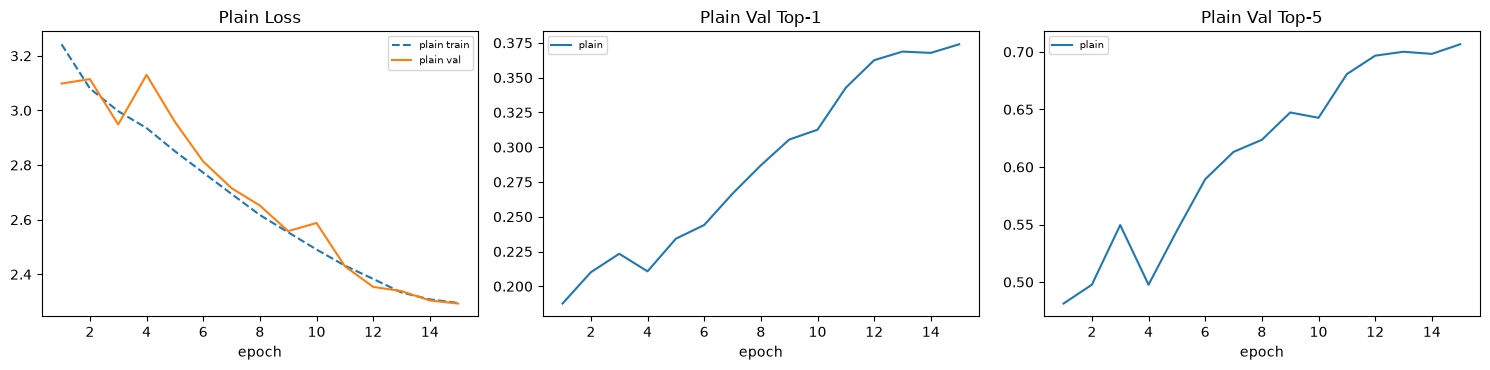

In [17]:
set_seed()
tr_loader, va_loader = make_loaders(False, batch=PLAIN_HP["batch"])
plain = PlainCNN(NUM_CLASSES, PLAIN_HP["width"], PLAIN_HP["dropout"])
HIST["plain"] = fit(plain, tr_loader, va_loader, CFG["EPOCHS_PLAIN"], PLAIN_HP["lr"],
                    PLAIN_HP["opt"], PLAIN_HP["wd"], PLAIN_HP["ls"], tag="Plain")
MODELS["plain"] = plain; PARAMS["plain"] = count_params(plain)

best = HIST["plain"].sort_values("val_top1").iloc[-1]
print(f"\n[Plain CNN | 驗證集 Fold {CFG['FOLD']}] Top-1 = {best.val_top1:.4f} | Top-5 = {best.val_top5:.4f}")
plot_history({"plain": HIST["plain"]}, "Plain")

## 2-2 Plain CNN 預測 Testing Dataset

使用驗證 Top-1 最佳的權重預測獨立的 `test/`（4,141 張），並將每張影像的真實類別、預測類別、信心值、Top-5 預測與是否正確存成 `outputs/test_pred_plain.csv`

In [18]:
df_plain = test_report("plain", MODELS["plain"])
per_class_summary(df_plain)
df_plain.head()

[plain] Test Top-1 = 0.3151 | Top-5 = 0.6419 | 已存 outputs\test_pred_plain.csv
預測最差的 10 個類別：
true
Bear          0.0
Woodpecker    0.0
Tortoise      0.0
Swan          0.0
Sea lion      0.0
Scorpion      0.0
Red panda     0.0
Panda         0.0
Mouse         0.0
Worm          0.0

部分錯誤預測：
 true       pred  confidence
Bear Rhinoceros      0.2397
Bear     Monkey      0.3524
Bear     Lizard      0.1753
Bear     Lizard      0.1609
Bear     Monkey      0.2717
Bear     Monkey      0.3117
Bear     Monkey      0.3360
Bear       Deer      0.1433


,path,true,pred,confidence,top5,correct
0,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Rhinoceros,0.2397,Rhinoceros|Monkey|Polar bear|Bear|Lion,False
1,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Monkey,0.3524,Monkey|Rhinoceros|Lion|Polar bear|Camel,False
2,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Lizard,0.1753,Lizard|Tortoise|Squirrel|Snake|Moths and butte...,False
3,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Lizard,0.1609,Lizard|Butterfly|Chicken|Moths and butterflies...,False
4,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Monkey,0.2717,Monkey|Rhinoceros|Polar bear|Lion|Bear,False


## 2-3 經典 CNN Backbone：ResNet-18（ImageNet 預訓練）

- 載入 torchvision 的 ImageNet 預訓練權重，將最後的 `fc` 換成 `NUM_CLASSES` 維輸出，整個網路微調（fine-tune）。
- 選 ResNet-18 的原因：殘差連接讓訓練穩定、參數量適中（約 11M），在單張 GPU 上訓練成本合理。
- 輸入使用與預訓練相同的 ImageNet 正規化。

[ResNet18] ep 01/15 | loss 1.099/0.939 | top1 0.707/0.722 | top5 0.945 | 15s
[ResNet18] ep 02/15 | loss 0.319/0.684 | top1 0.913/0.795 | top5 0.969 | 15s
[ResNet18] ep 03/15 | loss 0.109/0.763 | top1 0.975/0.783 | top5 0.964 | 15s
[ResNet18] ep 04/15 | loss 0.054/0.699 | top1 0.987/0.813 | top5 0.971 | 15s
[ResNet18] ep 05/15 | loss 0.032/0.876 | top1 0.994/0.772 | top5 0.962 | 15s
[ResNet18] ep 06/15 | loss 0.025/0.828 | top1 0.994/0.793 | top5 0.961 | 15s
[ResNet18] ep 07/15 | loss 0.018/0.676 | top1 0.997/0.823 | top5 0.972 | 15s
[ResNet18] ep 08/15 | loss 0.007/0.622 | top1 0.999/0.842 | top5 0.974 | 15s
[ResNet18] ep 09/15 | loss 0.002/0.604 | top1 1.000/0.843 | top5 0.976 | 15s
[ResNet18] ep 10/15 | loss 0.002/0.598 | top1 1.000/0.844 | top5 0.977 | 15s
[ResNet18] ep 11/15 | loss 0.001/0.598 | top1 1.000/0.848 | top5 0.977 | 15s
[ResNet18] ep 12/15 | loss 0.001/0.592 | top1 1.000/0.848 | top5 0.977 | 15s
[ResNet18] ep 13/15 | loss 0.001/0.588 | top1 1.000/0.853 | top5 0.978 | 15s

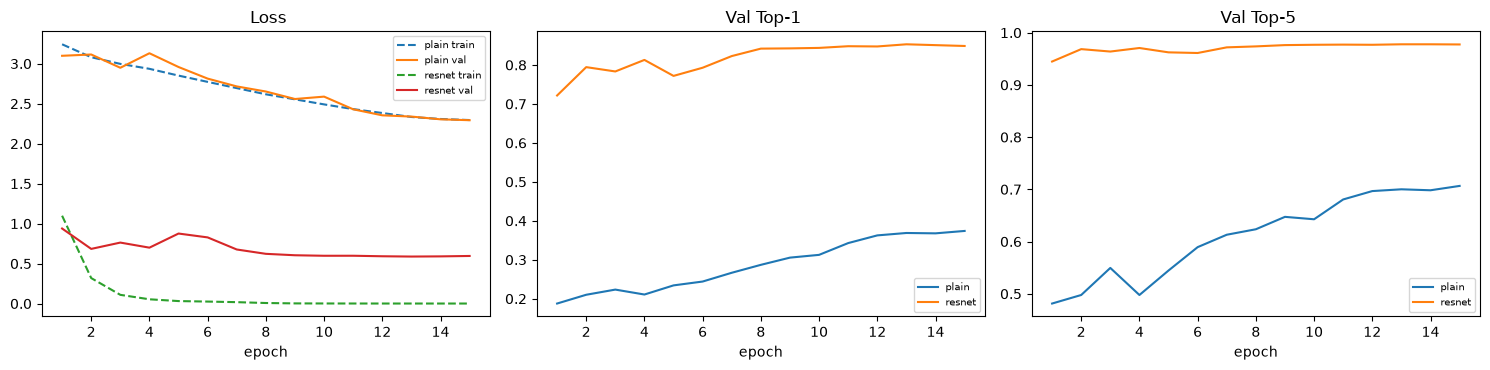

In [19]:
def build_resnet(num_classes, freeze=False):
    m = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    if freeze:
        for p in m.parameters():
            p.requires_grad = False
    m.fc = nn.Linear(m.fc.in_features, num_classes)   # 新的分類頭，一定要訓練
    return m

set_seed()
tr_loader, va_loader = make_loaders(False, batch=RESNET_HP["batch"])
resnet = build_resnet(NUM_CLASSES, RESNET_HP["freeze"])
HIST["resnet"] = fit(resnet, tr_loader, va_loader, CFG["EPOCHS_RESNET"], RESNET_HP["lr"],
                     RESNET_HP["opt"], RESNET_HP["wd"], RESNET_HP["ls"], tag="ResNet18")
MODELS["resnet"] = resnet; PARAMS["resnet"] = count_params(resnet)

best = HIST["resnet"].sort_values("val_top1").iloc[-1]
print(f"\n[ResNet-18 | 驗證集 Fold {CFG['FOLD']}] Top-1 = {best.val_top1:.4f} | Top-5 = {best.val_top5:.4f}")
print(f"ResNet-18 參數量: {PARAMS['resnet']:,}")
plot_history({"plain": HIST["plain"], "resnet": HIST["resnet"]}, "")

## 2-4 ResNet-18 預測 Testing Dataset

In [20]:
df_resnet = test_report("resnet", MODELS["resnet"])
per_class_summary(df_resnet)
df_resnet.head()

[resnet] Test Top-1 = 0.8696 | Top-5 = 0.9833 | 已存 outputs\test_pred_resnet.csv
預測最差的 10 個類別：
true
Jaguar                   0.000
Worm                     0.385
Sea lion                 0.500
Moths and butterflies    0.538
Goldfish                 0.542
Cattle                   0.596
Camel                    0.667
Red panda                0.679
Mouse                    0.697
Lynx                     0.706

部分錯誤預測：
      true       pred  confidence
     Bear     Parrot      0.3794
     Bear Polar bear      0.9967
     Bear Polar bear      0.9939
     Bear     Monkey      0.4955
     Bear   Squirrel      0.5885
     Bear     Monkey      0.6189
     Bear     Monkey      0.5287
Butterfly     Spider      0.6786


,path,true,pred,confidence,top5,correct
0,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Bear,0.9876,Bear|Red panda|Monkey|Panda|Cattle,True
1,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Bear,0.8660,Bear|Monkey|Red panda|Mouse|Panda,True
2,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Bear,0.9672,Bear|Monkey|Elephant|Lion|Mouse,True
3,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Parrot,0.3794,Parrot|Chicken|Snake|Swan|Penguin,False
4,C:\Users\GM100\.cache\kagglehub\datasets\antor...,Bear,Bear,0.9998,Bear|Monkey|Red panda|Cattle|Elephant,True


## 2-5 各類別 ROC Curve、Macro-AUC，並比較 Accuracy 與參數量

做法：對每個類別 c，把「真實類別 = c」視為正例、其餘為負例（One-vs-Rest），
用模型對類別 c 的 Softmax 機率計算 ROC 與 AUC；**Macro-AUC = 所有類別 AUC 的算術平均**。
圖中淡色細線為各類別 ROC，粗線為對各類別 TPR 內插後平均的 Macro ROC。

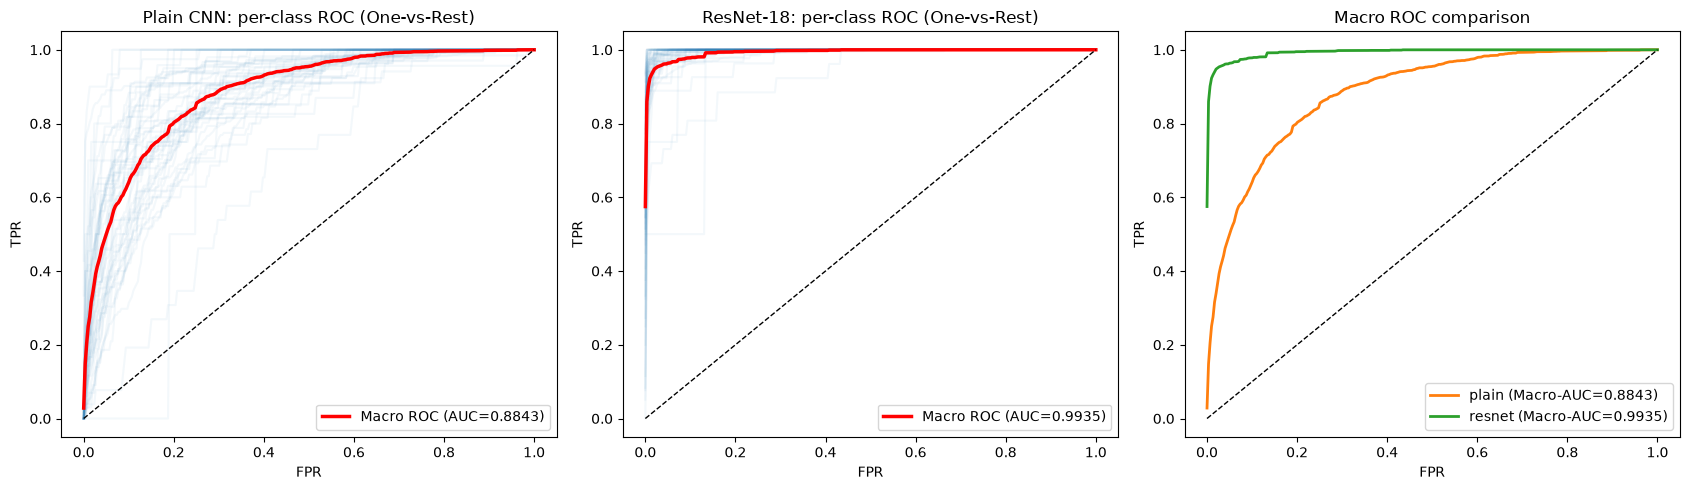

plain AUC 最低的類別: [('Moths and butterflies', 0.6734), ('Sea lion', 0.7805), ('Mouse', 0.7924), ('Squirrel', 0.803), ('Deer', 0.8069)]
resnet AUC 最低的類別: [('Sea lion', 0.9334), ('Moths and butterflies', 0.9355), ('Bear', 0.9781), ('Jaguar', 0.9805), ('Fish', 0.9866)]


In [21]:
def roc_analysis(name):
    probs, y = PROBS[name]
    grid = np.linspace(0, 1, 300); tprs, aucs = [], {}
    for c in range(probs.shape[1]):
        yt = (y == c).astype(int)
        if yt.sum() == 0 or yt.sum() == len(yt):
            continue
        fpr, tpr, _ = roc_curve(yt, probs[:, c])
        aucs[c] = auc(fpr, tpr); tprs.append(np.interp(grid, fpr, tpr))
    return grid, np.mean(tprs, 0), tprs, aucs

ROC = {n: roc_analysis(n) for n in ["plain", "resnet"]}
for n in ROC:
    TEST[n]["macro_auc"] = float(np.mean(list(ROC[n][3].values())))

fig, ax = plt.subplots(1, 3, figsize=(17, 5))
for a, n, title in zip(ax[:2], ["plain", "resnet"], ["Plain CNN", "ResNet-18"]):
    grid, macro, tprs, aucs = ROC[n]
    for t in tprs:
        a.plot(grid, t, color="tab:blue", alpha=0.05)
    a.plot(grid, macro, color="red", lw=2.5, label=f"Macro ROC (AUC={TEST[n]['macro_auc']:.4f})")
    a.plot([0, 1], [0, 1], "k--", lw=1)
    a.set_title(f"{title}: per-class ROC (One-vs-Rest)"); a.set_xlabel("FPR"); a.set_ylabel("TPR"); a.legend(loc="lower right")
for n, c in [("plain", "tab:orange"), ("resnet", "tab:green")]:
    ax[2].plot(ROC[n][0], ROC[n][1], color=c, lw=2, label=f"{n} (Macro-AUC={TEST[n]['macro_auc']:.4f})")
ax[2].plot([0, 1], [0, 1], "k--", lw=1); ax[2].set_title("Macro ROC comparison"); ax[2].legend(loc="lower right")
ax[2].set_xlabel("FPR"); ax[2].set_ylabel("TPR")
plt.tight_layout(); plt.savefig(OUT / "roc_compare.png", dpi=150); plt.show()

# 各自 AUC 最低的 5 個類別
for n in ROC:
    low = sorted(ROC[n][3].items(), key=lambda kv: kv[1])[:5]
    print(n, "AUC 最低的類別:", [(CLASSES[c], round(a, 4)) for c, a in low])

In [22]:
compare = pd.DataFrame([
    dict(model="Plain CNN", params=PARAMS["plain"],
         val_top1=HIST["plain"].val_top1.max(), val_top5=HIST["plain"].val_top5.max(),
         test_top1=TEST["plain"]["top1"], test_top5=TEST["plain"]["top5"], test_macro_auc=TEST["plain"]["macro_auc"]),
    dict(model="ResNet-18 (pretrained)", params=PARAMS["resnet"],
         val_top1=HIST["resnet"].val_top1.max(), val_top5=HIST["resnet"].val_top5.max(),
         test_top1=TEST["resnet"]["top1"], test_top5=TEST["resnet"]["top5"], test_macro_auc=TEST["resnet"]["macro_auc"]),
]).set_index("model")
compare["params(M)"] = (compare.params / 1e6).round(2)
compare["top1 per M params"] = (compare.test_top1 / compare["params(M)"]).round(4)
compare.to_csv(OUT / "compare_basic.csv")
display(compare.round(4))

,params,val_top1,val_top5,test_top1,test_top5,test_macro_auc,params(M),top1 per M params
model,,,,,,,,
Plain CNN,1186066,0.3740,0.7066,0.3151,0.6419,0.8843,1.19,0.2648
ResNet-18 (pretrained),11202162,0.8531,0.9778,0.8696,0.9833,0.9935,11.20,0.0776


### 比較與討論：準確率與參數量
| 模型 |	參數量	| 驗證 Top-1	| 驗證 Top-5	| 測試 Top-1	| 測試 Top-5	| 測試 Macro-AUC	| 每百萬參數的 Top-1| 
| --- | --- | --- | --- | --- | --- | --- | --- | 
| Plain CNN	| 1.19M	| 37.40%	| 70.66%	| 31.51%	| 64.19%	| 0.8843	| 0.2648 | 
| ResNet-18（預訓練）| 	11.20M	| 85.31%	| 97.78%	| 86.96%	| 98.33%	| 0.9935	| 0.0776 | 


- 準確率：
  - ResNet-18 在所有指標上都大幅領先，測試 Top-1 高出 55.45 個百分點、Top-5 高出 34.14 個百分點、Macro-AUC 高出 0.109。
  - 主要原因是 ImageNet 預訓練已提供良好的底層與中層特徵，而 Plain CNN 只能從 12,960 張訓練影像從頭學起。
- 參數量：
  - ResNet-18 的參數量約為 Plain CNN 的 9.4 倍。
  - 若用「每百萬參數的 Top-1」衡量，Plain CNN（0.2648）高於 ResNet-18（0.0776），但這是因為 Plain CNN 的絕對準確率太低；以實際可用性來看，多用的參數換到了大幅提升的準確率，ResNet-18 更划算。
- Top-5 與 Top-1 的差距：
  - Plain CNN 為 32.68 個百分點，ResNet-18 只有 11.37 個百分點。
  - Plain CNN 常常連前 5 名都找不到正確答案；ResNet-18 多數錯誤只是在相近類別之間排錯順序（例如 Bear 與 Polar bear）。
- Macro-AUC 與 Accuracy：
  - Macro-AUC（0.8843、0.9935）遠高於 Accuracy，因為類別多時 One-vs-Rest 的負例遠多於正例，容易得到高 AUC。
  - AUC 反映的是排序能力，Accuracy 反映的是最終決策，兩者要一起看。
  - 例如 ResNet-18 的 Jaguar 測試準確率為 0%，但 AUC 仍有 0.981。
- 類別不平衡的影響：
  - Plain CNN 有 10 個以上類別的測試準確率為 0，推測與訓練池類別不平衡（最大 / 最小為 46.9 : 1）有關：模型傾向預測樣本數多的類別。

# Quiz 3：提升泛化能力

## 3-1 / 3-2 Data Augmentation

**擴增策略（只作用在訓練集，驗證 / 測試集維持原樣）：**

| 方法 | 設定 | 理由 |
|---|---|---|
| RandomResizedCrop | scale 0.5–1.0 | 模擬不同拍攝距離與構圖，迫使模型不依賴固定位置 |
| RandomHorizontalFlip | p=0.5 | 動物左右朝向都合理；**不做垂直翻轉**（不符合真實分佈） |
| RandomRotation | ±15° | 模擬拍攝角度與姿態的小幅變化 |
| ColorJitter | 亮度 / 對比 / 飽和度 ±0.3（不改色相） | 模擬光線變化；不動色相以免改變動物關鍵毛色 |
| RandomErasing | p=0.25 | 模擬遮擋（樹枝、葉片），降低對單一局部特徵的依賴 |

實作上這些擴增都在 GPU 上以 batch 為單位完成（每張圖各自隨機抽樣參數），避免 CPU 成為瓶頸。

預期：訓練準確率下降、train–val 差距縮小、驗證 / 測試準確率提升（尤其是容易過擬合的 Plain CNN）。

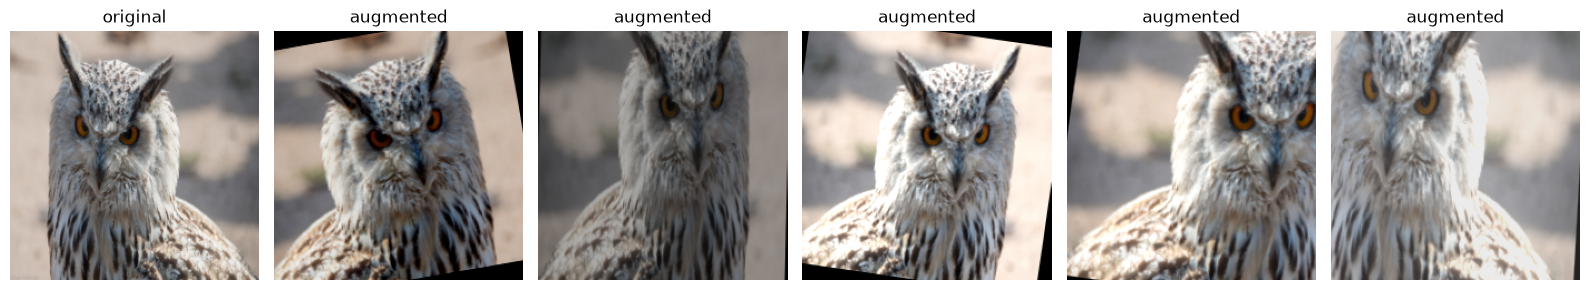

In [23]:
def denorm(t):
    return (t.detach().cpu() * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)).clamp(0, 1).permute(1, 2, 0).numpy()

# 同一張圖的原圖與 5 次擴增結果
idx = random.randrange(len(BASE_TRAIN))
x0 = X_TRAIN[idx:idx + 1].float().div(255)
aug_batch = random_erase((gpu_augment(x0.repeat(5, 1, 1, 1)) - MEAN_T) / STD_T)
fig, axs = plt.subplots(1, 6, figsize=(16, 3))
axs[0].imshow(x0[0].permute(1, 2, 0).cpu().numpy()); axs[0].set_title("original")
for a, im in zip(axs[1:], aug_batch):
    a.imshow(denorm(im)); a.set_title("augmented")
for a in axs: a.axis("off")
plt.tight_layout(); plt.show()

In [24]:
# --- Plain CNN + Augmentation ---
set_seed()
tr_a, va_a = make_loaders(True, batch=PLAIN_HP["batch"])
plain_aug = PlainCNN(NUM_CLASSES, PLAIN_HP["width"], PLAIN_HP["dropout"])
HIST["plain_aug"] = fit(plain_aug, tr_a, va_a, CFG["EPOCHS_PLAIN"], PLAIN_HP["lr"], PLAIN_HP["opt"],
                        PLAIN_HP["wd"], PLAIN_HP["ls"], tag="Plain+Aug")
MODELS["plain_aug"] = plain_aug; PARAMS["plain_aug"] = count_params(plain_aug)
_ = test_report("plain_aug", plain_aug)

# --- ResNet-18 + Augmentation ---
set_seed()
tr_a, va_a = make_loaders(True, batch=RESNET_HP["batch"])
resnet_aug = build_resnet(NUM_CLASSES, RESNET_HP["freeze"])
HIST["resnet_aug"] = fit(resnet_aug, tr_a, va_a, CFG["EPOCHS_RESNET"], RESNET_HP["lr"], RESNET_HP["opt"],
                         RESNET_HP["wd"], RESNET_HP["ls"], tag="ResNet+Aug")
MODELS["resnet_aug"] = resnet_aug; PARAMS["resnet_aug"] = count_params(resnet_aug)
_ = test_report("resnet_aug", resnet_aug)

[Plain+Aug] ep 01/15 | loss 3.286/3.155 | top1 0.164/0.183 | top5 0.479 | 28s
[Plain+Aug] ep 02/15 | loss 3.177/3.065 | top1 0.177/0.201 | top5 0.494 | 28s
[Plain+Aug] ep 03/15 | loss 3.114/3.067 | top1 0.192/0.198 | top5 0.515 | 28s
[Plain+Aug] ep 04/15 | loss 3.060/3.015 | top1 0.200/0.205 | top5 0.523 | 28s
[Plain+Aug] ep 05/15 | loss 3.013/2.998 | top1 0.204/0.220 | top5 0.525 | 28s
[Plain+Aug] ep 06/15 | loss 2.949/2.982 | top1 0.223/0.208 | top5 0.521 | 28s
[Plain+Aug] ep 07/15 | loss 2.891/2.829 | top1 0.227/0.246 | top5 0.571 | 28s
[Plain+Aug] ep 08/15 | loss 2.823/2.727 | top1 0.245/0.267 | top5 0.607 | 28s
[Plain+Aug] ep 09/15 | loss 2.755/2.746 | top1 0.259/0.264 | top5 0.593 | 28s
[Plain+Aug] ep 10/15 | loss 2.693/2.806 | top1 0.268/0.251 | top5 0.584 | 28s
[Plain+Aug] ep 11/15 | loss 2.636/2.647 | top1 0.282/0.297 | top5 0.628 | 28s
[Plain+Aug] ep 12/15 | loss 2.605/2.614 | top1 0.290/0.308 | top5 0.633 | 28s
[Plain+Aug] ep 13/15 | loss 2.557/2.554 | top1 0.306/0.312 | top

,model,augmentation,final_train_top1,best_val_top1,best_val_top5,gap_train_minus_val,test_top1,test_top5
0,Plain CNN,No,0.3601,0.3740,0.7066,-0.0138,0.3151,0.6419
1,Plain CNN,Yes,0.3080,0.3261,0.6581,-0.0181,0.2738,0.5892
2,ResNet-18,No,1.0000,0.8531,0.9778,0.1512,0.8696,0.9833
3,ResNet-18,Yes,0.9899,0.8497,0.9772,0.1401,0.8611,0.9797


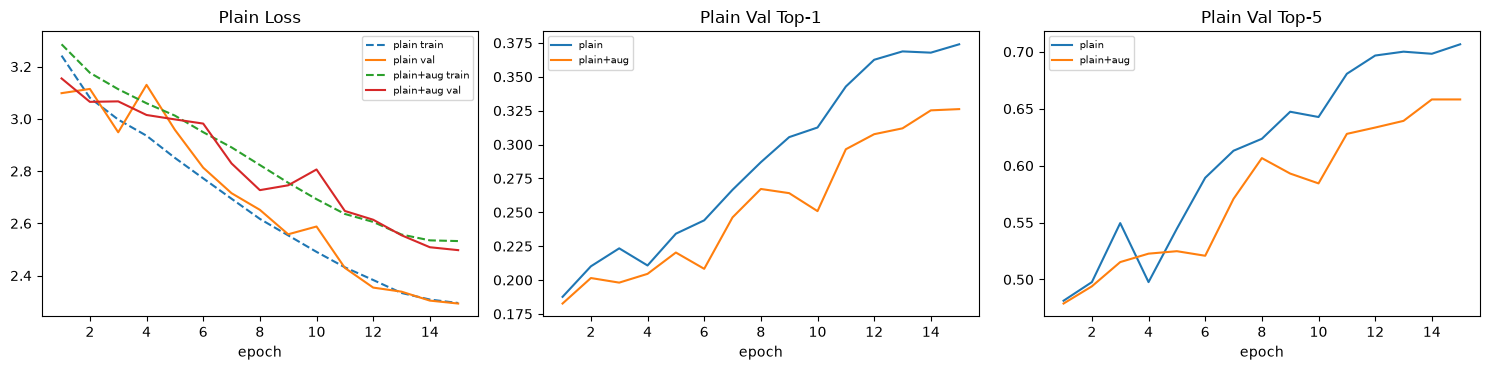

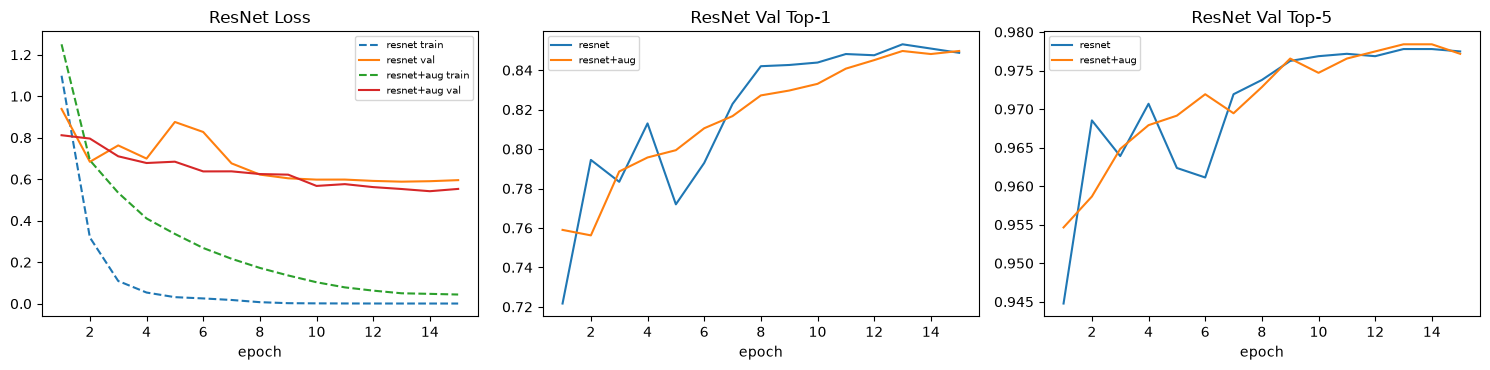

In [25]:
rows = []
for name, label, aug in [("plain", "Plain CNN", "No"), ("plain_aug", "Plain CNN", "Yes"),
                         ("resnet", "ResNet-18", "No"), ("resnet_aug", "ResNet-18", "Yes")]:
    h = HIST[name]; b = h.sort_values("val_top1").iloc[-1]
    rows.append(dict(model=label, augmentation=aug,
                     final_train_top1=h.train_top1.iloc[-1], best_val_top1=b.val_top1, best_val_top5=b.val_top5,
                     gap_train_minus_val=h.train_top1.iloc[-1] - h.val_top1.iloc[-1],
                     test_top1=TEST[name]["top1"], test_top5=TEST[name]["top5"]))
aug_cmp = pd.DataFrame(rows)
aug_cmp.to_csv(OUT / "compare_augmentation.csv", index=False)
display(aug_cmp.round(4))

plot_history({"plain": HIST["plain"], "plain+aug": HIST["plain_aug"]}, "Plain")
plot_history({"resnet": HIST["resnet"], "resnet+aug": HIST["resnet_aug"]}, "ResNet")

### 擴增前後比較與分析
#### 3-1 Plain CNN：擴增前 vs 擴增後
| 指標	| 無擴增 | 	有擴增	| 變化|
| ---|  --- | --- | --- |
| 最終訓練|  Top-1	| 36.01%| 	30.80%	| −5.21| 
| 最佳驗證 Top-1	| 37.40%	| 32.61%| 	−4.79| 
| 最佳驗證 Top-5	| 70.66%| 	65.81%| 	−4.85| 
| 測試 Top-1| 	31.51%	| 27.38%| 	−4.13| 
| 測試 Top-5| 	64.19%| 	58.92%| 	−5.27| 

#### 3-2 ResNet-18：擴增前 vs 擴增後
|指標|	無擴增|	有擴增	|變化|
| ---|  --- | --- | --- |
|最終訓練 Top-1	|100.00%	|98.99%	|−1.01|
|最佳驗證 Top-1	|85.31%	|84.97%	|−0.34|
|最佳驗證 Top-5	|97.78%	|97.72%	|−0.06|
|訓練 − 驗證 Top-1 差距|	15.12	|14.01	|−1.11|
|最低驗證 Loss	|0.588|	0.542|	−0.046|
|測試 Top-1	|86.96%	|86.11%|	−0.85|
|測試 Top-5	|98.33%	|97.97%	|−0.36|
#### 分析
- Plain CNN：
  - 擴增沒有幫助，反而讓表現下降。 
  - 無擴增時，訓練 Top-1（36.0%）本來就低於驗證（37.4%），代表模型沒有過擬合，瓶頸是模型容量與訓練 epoch 不足（欠擬合）。在這種情況下，擴增讓學習任務變得更難，15 個 epoch 內模型還來不及適應，因此訓練、驗證與測試表現都下降。
  - 擴增後的訓練 Top-1 是在「已擴增」的影像上計算，訓練準確率低於驗證屬於正常現象，不能用「訓練 − 驗證差距」判斷過擬合是否改善。
- ResNet-18：
  - 擴增發揮了正則化效果，但準確率沒有提升。 
  - 擴增後訓練 Top-1 由 100% 降到 98.99%，訓練與驗證的差距縮小 1.11 個百分點，最低驗證 Loss 也由 0.588 降到 0.542，表示過擬合有減輕、預測的信心值較合理。
  - 但 Top-1 / Top-5 在驗證與測試集都略微下降（測試 Top-1 −0.85 個百分點）。不過這個差距很小，而且只有單次實驗（單一 fold、單一亂數種子），不能據此斷定擴增對 ResNet-18 有害。
- 可能原因與後續改進方向（以下為推測，需要另外實驗驗證）：
  - 預訓練的 ResNet-18 本身已具備不錯的泛化特徵，15 個 epoch 的訓練預算下，較強的擴增還來不及發揮效果，可增加 epoch 數
  - 擴增強度可能偏強（例如裁切面積下限 0.5，加上遮擋與旋轉），而資料集中動物本來就常只佔畫面一小部分，裁切可能把動物裁掉；可降低裁切強度（如面積比例 0.7 ～ 1.0）或移除 RandomErasing
  - Plain CNN 應先提高模型容量（例如增加 width）或訓練更多 epoch，讓模型先擬合訓練資料，再加入擴增才會有明顯效益。

# 總結
| 項目| 	結論| 
|-- |-- | 
| 最佳模型| 	ResNet-18（ImageNet 預訓練、不使用擴增）：測試 Top-1 86.96%、Top-5 98.33%、Macro-AUC 0.9935| 
| Plain CNN vs ResNet-18	| Plain CNN：1.19M 參數、測試 Top-1 31.51%、Top-5 64.19%、Macro-AUC 0.8843；ResNet-18：11.20M 參數（約 9.4 倍）、測試 Top-1 86.96%、Top-5 98.33%、Macro-AUC 0.9935。預訓練模型以約 9.4 倍的參數換到 Top-1 高出 55.45 個百分點| 
| 資料擴增效果	| 本次設定下，兩個模型的測試表現都略為下降：Plain CNN（欠擬合）Top-1 −4.13 個百分點；ResNet-18 Top-1 −0.85 個百分點，但過擬合程度與驗證 Loss 有所改善。建議增加 epoch 數或降低擴增強度後再比較| 
| 資料集處理	| 移除標籤衝突影像 2,724 張，train / test 無資料洩漏；選用 50 類，訓練池 16,201 張、測試集 4,141 張| 

- 限制：所有結果皆為單一 fold（Fold 0）、單一亂數種子的單次實驗；Macro-AUC 只對未擴增的兩個模型計算。

- 輸出檔案皆存放於 `outputs/：test_pred_*.csv`（各模型的測試集預測結果）、`roc_compare.png`（ROC 曲線）、`compare_basic.csv`（Plain CNN 與 ResNet-18 比較表）、`compare_augmentation.csv`（擴增前後比較表）。